In [1]:
#Для работы с данными:
import numpy as np
import matplotlib.pyplot as plt
import tarfile #встроенный модуль для работы с tar-архивами
import os
import nibabel as nib
import random
import glob #встроенный модуль для поиска файлов, соответстсвующих определенному шаблону в дереве каталогов
import tensorflow as tf

2025-05-30 20:11:51.548980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748625113.320317    9417 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748625113.824300    9417 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748625119.478670    9417 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748625119.478701    9417 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748625119.478703    9417 computation_placer.cc:177] computation placer alr

In [2]:
from keras.models import Model, load_model
from keras.layers import Input, Conv3D, MaxPooling3D, concatenate, Conv3DTranspose, BatchNormalization, Activation, Dropout
from keras.optimizers import Adam
import numpy as np

In [3]:
from tensorflow.keras.utils import to_categorical

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Работа с данными

In [4]:
file = tarfile.open('/mnt/e/BRaTS/archive (1)/archive (1)/BraTS2021_Training_Data.tar')

file.extractall('/mnt/e/BRaTS/archive (1)/BraTS2021_Training_Data') #извлекли данные мрт из архива в папку по указанному пути
file.close()

In [4]:
scaler = MinMaxScaler()

In [5]:
t1ce_s = sorted(glob.glob('/mnt/e/BRaTS/archive (1)/BraTS2021_Training_Data/*/*t1ce.nii.gz'))
flair_s = sorted(glob.glob('/mnt/e/BRaTS/archive (1)/BraTS2021_Training_Data/*/*flair.nii.gz'))
t2_s = sorted(glob.glob('/mnt/e/BRaTS/archive (1)/BraTS2021_Training_Data/*/*t2.nii.gz'))
masks = sorted(glob.glob('/mnt/e/BRaTS/archive (1)/BraTS2021_Training_Data/*/*seg.nii.gz'))

In [7]:
for im in range(len(t1ce_s)):
    print('Обрабатываем МРТ под номером:', im)
    temp_t1ce = nib.load(t1ce_s[im]).get_fdata()
    temp_t1ce = scaler.fit_transform(temp_t1ce.reshape(-1, temp_t1ce.shape[-1])).reshape(temp_t1ce.shape)
    
    temp_t2 = nib.load(t2_s[im]).get_fdata()
    temp_t2 = scaler.fit_transform(temp_t2.reshape(-1, temp_t2.shape[-1])).reshape(temp_t2.shape)
    
    temp_flair = nib.load(flair_s[im]).get_fdata()
    temp_flair = scaler.fit_transform(temp_flair.reshape(-1, temp_flair.shape[-1])).reshape(temp_flair.shape)
    
    temp_mask = nib.load(masks[im]).get_fdata()
    temp_mask = temp_mask.astype(np.uint8)
    temp_mask[temp_mask==4] = 3
    
    temp_combo = np.stack([temp_t1ce, temp_t2, temp_flair], axis = 3)
    
    temp_combo = temp_combo[56:184, 56:184, 13:141]
    temp_mask = temp_mask[56:184, 56:184, 13:141]
    
    temp_mask = to_categorical(temp_mask, num_classes=4)
    
    np.save(f'/mnt/e/BRaTS/archive (1)/Input/MRIs/MRI_{im}.npy', temp_combo)
    np.save(f'/mnt/e/BRaTS/archive (1)/Input/masks/mask_{im}.npy', temp_mask)

Обрабатываем МРТ под номером: 0
Обрабатываем МРТ под номером: 1
Обрабатываем МРТ под номером: 2
Обрабатываем МРТ под номером: 3
Обрабатываем МРТ под номером: 4
Обрабатываем МРТ под номером: 5
Обрабатываем МРТ под номером: 6
Обрабатываем МРТ под номером: 7
Обрабатываем МРТ под номером: 8
Обрабатываем МРТ под номером: 9
Обрабатываем МРТ под номером: 10
Обрабатываем МРТ под номером: 11
Обрабатываем МРТ под номером: 12
Обрабатываем МРТ под номером: 13
Обрабатываем МРТ под номером: 14
Обрабатываем МРТ под номером: 15
Обрабатываем МРТ под номером: 16
Обрабатываем МРТ под номером: 17
Обрабатываем МРТ под номером: 18
Обрабатываем МРТ под номером: 19
Обрабатываем МРТ под номером: 20
Обрабатываем МРТ под номером: 21
Обрабатываем МРТ под номером: 22
Обрабатываем МРТ под номером: 23
Обрабатываем МРТ под номером: 24
Обрабатываем МРТ под номером: 25
Обрабатываем МРТ под номером: 26
Обрабатываем МРТ под номером: 27
Обрабатываем МРТ под номером: 28
Обрабатываем МРТ под номером: 29
Обрабатываем МРТ под

Обрабатываем МРТшечку под номером: 213
Обрабатываем МРТшечку под номером: 214
Обрабатываем МРТшечку под номером: 215
Обрабатываем МРТшечку под номером: 216
Обрабатываем МРТшечку под номером: 217
Обрабатываем МРТшечку под номером: 218
Обрабатываем МРТшечку под номером: 219
Обрабатываем МРТшечку под номером: 220
Обрабатываем МРТшечку под номером: 221
Обрабатываем МРТшечку под номером: 222
Обрабатываем МРТшечку под номером: 223
Обрабатываем МРТшечку под номером: 224
Обрабатываем МРТшечку под номером: 225
Обрабатываем МРТшечку под номером: 226
Обрабатываем МРТшечку под номером: 227
Обрабатываем МРТшечку под номером: 228
Обрабатываем МРТшечку под номером: 229
Обрабатываем МРТшечку под номером: 230
Обрабатываем МРТшечку под номером: 231
Обрабатываем МРТшечку под номером: 232
Обрабатываем МРТшечку под номером: 233
Обрабатываем МРТшечку под номером: 234
Обрабатываем МРТшечку под номером: 235
Обрабатываем МРТшечку под номером: 236
Обрабатываем МРТшечку под номером: 237
Обрабатываем МРТшечку под

Обрабатываем МРТшечку под номером: 424
Обрабатываем МРТшечку под номером: 425
Обрабатываем МРТшечку под номером: 426
Обрабатываем МРТшечку под номером: 427
Обрабатываем МРТшечку под номером: 428
Обрабатываем МРТшечку под номером: 429
Обрабатываем МРТшечку под номером: 430
Обрабатываем МРТшечку под номером: 431
Обрабатываем МРТшечку под номером: 432
Обрабатываем МРТшечку под номером: 433
Обрабатываем МРТшечку под номером: 434
Обрабатываем МРТшечку под номером: 435
Обрабатываем МРТшечку под номером: 436
Обрабатываем МРТшечку под номером: 437
Обрабатываем МРТшечку под номером: 438
Обрабатываем МРТшечку под номером: 439
Обрабатываем МРТшечку под номером: 440
Обрабатываем МРТшечку под номером: 441
Обрабатываем МРТшечку под номером: 442
Обрабатываем МРТшечку под номером: 443
Обрабатываем МРТшечку под номером: 444
Обрабатываем МРТшечку под номером: 445
Обрабатываем МРТшечку под номером: 446
Обрабатываем МРТшечку под номером: 447
Обрабатываем МРТшечку под номером: 448
Обрабатываем МРТшечку под

Обрабатываем МРТшечку под номером: 635
Обрабатываем МРТшечку под номером: 636
Обрабатываем МРТшечку под номером: 637
Обрабатываем МРТшечку под номером: 638
Обрабатываем МРТшечку под номером: 639
Обрабатываем МРТшечку под номером: 640
Обрабатываем МРТшечку под номером: 641
Обрабатываем МРТшечку под номером: 642
Обрабатываем МРТшечку под номером: 643
Обрабатываем МРТшечку под номером: 644
Обрабатываем МРТшечку под номером: 645
Обрабатываем МРТшечку под номером: 646
Обрабатываем МРТшечку под номером: 647
Обрабатываем МРТшечку под номером: 648
Обрабатываем МРТшечку под номером: 649
Обрабатываем МРТшечку под номером: 650
Обрабатываем МРТшечку под номером: 651
Обрабатываем МРТшечку под номером: 652
Обрабатываем МРТшечку под номером: 653
Обрабатываем МРТшечку под номером: 654
Обрабатываем МРТшечку под номером: 655
Обрабатываем МРТшечку под номером: 656
Обрабатываем МРТшечку под номером: 657
Обрабатываем МРТшечку под номером: 658
Обрабатываем МРТшечку под номером: 659
Обрабатываем МРТшечку под

Обрабатываем МРТшечку под номером: 846
Обрабатываем МРТшечку под номером: 847
Обрабатываем МРТшечку под номером: 848
Обрабатываем МРТшечку под номером: 849
Обрабатываем МРТшечку под номером: 850
Обрабатываем МРТшечку под номером: 851
Обрабатываем МРТшечку под номером: 852
Обрабатываем МРТшечку под номером: 853
Обрабатываем МРТшечку под номером: 854
Обрабатываем МРТшечку под номером: 855
Обрабатываем МРТшечку под номером: 856
Обрабатываем МРТшечку под номером: 857
Обрабатываем МРТшечку под номером: 858
Обрабатываем МРТшечку под номером: 859
Обрабатываем МРТшечку под номером: 860
Обрабатываем МРТшечку под номером: 861
Обрабатываем МРТшечку под номером: 862
Обрабатываем МРТшечку под номером: 863
Обрабатываем МРТшечку под номером: 864
Обрабатываем МРТшечку под номером: 865
Обрабатываем МРТшечку под номером: 866
Обрабатываем МРТшечку под номером: 867
Обрабатываем МРТшечку под номером: 868
Обрабатываем МРТшечку под номером: 869
Обрабатываем МРТшечку под номером: 870
Обрабатываем МРТшечку под

Обрабатываем МРТшечку под номером: 1055
Обрабатываем МРТшечку под номером: 1056
Обрабатываем МРТшечку под номером: 1057
Обрабатываем МРТшечку под номером: 1058
Обрабатываем МРТшечку под номером: 1059
Обрабатываем МРТшечку под номером: 1060
Обрабатываем МРТшечку под номером: 1061
Обрабатываем МРТшечку под номером: 1062
Обрабатываем МРТшечку под номером: 1063
Обрабатываем МРТшечку под номером: 1064
Обрабатываем МРТшечку под номером: 1065
Обрабатываем МРТшечку под номером: 1066
Обрабатываем МРТшечку под номером: 1067
Обрабатываем МРТшечку под номером: 1068
Обрабатываем МРТшечку под номером: 1069
Обрабатываем МРТшечку под номером: 1070
Обрабатываем МРТшечку под номером: 1071
Обрабатываем МРТшечку под номером: 1072
Обрабатываем МРТшечку под номером: 1073
Обрабатываем МРТшечку под номером: 1074
Обрабатываем МРТшечку под номером: 1075
Обрабатываем МРТшечку под номером: 1076
Обрабатываем МРТшечку под номером: 1077
Обрабатываем МРТшечку под номером: 1078
Обрабатываем МРТшечку под номером: 1079


In [2]:
import splitfolders

inp_fold = '/mnt/e/BRaTS/archive (1)/Input/'
out_fold = '/mnt/e/BRaTS/archive (1)/split_data/'

splitfolders.ratio(inp_fold, output=out_fold, seed=1337, ratio=(.8, .1, .1), group_prefix=None)

# Кастомный генератор данных

In [5]:
def MRI_load(directory, im_list):
    images = []
    for i, img_name in enumerate(im_list):
        if img_name.split('.')[1] == 'npy':
            image = np.load(directory + img_name)
            images.append(image)
    images = np.array(images)
    
    return(images)

In [6]:
def MRI_generator(directory, im_list, mask_directory, mask_list, batch_size):
    L = len(im_list)
    
    while True:
        
        batch_start = 0
        batch_end = batch_size
        
        while batch_start < L:
            limit = min(batch_end, L)
            
            X = MRI_load(directory, im_list[batch_start:limit])
            Y = MRI_load(mask_directory, mask_list[batch_start:limit])
            
            yield (X, Y)
            
            batch_start += batch_size
            batch_end += batch_size

# UNet-3D

In [7]:
kernel_initializer = 'he_uniform'
def UNet_3D_mine(height, width, depth, channels, classes):
    inputs = Input((height, width, depth, channels))
    #encoder
    conv_block1 = Conv3D(16, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(inputs)
    batchnorm_block1 = BatchNormalization()(conv_block1)
    act_block1 = Activation('relu')(batchnorm_block1)
    conv_block1 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block1)
    batchnorm_block1 = BatchNormalization()(conv_block1)
    act_block1 = Activation('relu')(batchnorm_block1)
    maxpool_block1 = MaxPooling3D((2, 2, 2))(act_block1)

    conv_block2 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block1)
    batchnorm_block2 = BatchNormalization()(conv_block2)
    act_block2 = Activation('relu')(batchnorm_block2)
    conv_block2 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block2)
    batchnorm_block2 = BatchNormalization()(conv_block2)
    act_block2 = Activation('relu')(batchnorm_block2)
    maxpool_block2 = MaxPooling3D((2, 2, 2))(act_block2)

    conv_block3 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block2)
    batchnorm_block3 = BatchNormalization()(conv_block3)
    act_block3 = Activation('relu')(batchnorm_block3)
    conv_block3 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block3)
    batchnorm_block3 = BatchNormalization()(conv_block3)
    act_block3 = Activation('relu')(batchnorm_block3)
    maxpool_block3 = MaxPooling3D((2, 2, 2))(act_block3)

    conv_block4 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block3)
    batchnorm_block4 = BatchNormalization()(conv_block4)
    act_block4 = Activation('relu')(batchnorm_block4)
    conv_block4 = Conv3D(256, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block4)
    batchnorm_block4 = BatchNormalization()(conv_block4)
    act_block4 = Activation('relu')(batchnorm_block4)

    upconv_block5 =  Conv3DTranspose(256, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block4)
    concat_block5 = concatenate([upconv_block5, act_block3])
    conv_block5 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block5)
    batchnorm_block5 = BatchNormalization()(conv_block5)
    act_block5 = Activation('relu')(batchnorm_block5)
    conv_block5 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block5)
    batchnorm_block5 = BatchNormalization()(conv_block5)
    act_block5 = Activation('relu')(batchnorm_block5)

    upconv_block6 =  Conv3DTranspose(128, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block5)
    concat_block6 = concatenate([upconv_block6, act_block2])
    conv_block6 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block6)
    batchnorm_block6 = BatchNormalization()(conv_block6)
    act_block6 = Activation('relu')(batchnorm_block6)
    conv_block6 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block6)
    batchnorm_block6 = BatchNormalization()(conv_block6)
    act_block6 = Activation('relu')(batchnorm_block6)

    upconv_block7 = Conv3DTranspose(32, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block6)
    concat_block7 = concatenate([upconv_block7, act_block1])
    conv_block7 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block7)
    batchnorm_block7 = BatchNormalization()(conv_block7)
    act_block7 = Activation('relu')(batchnorm_block7)
    conv_block7 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block7)
    batchnorm_block7 = BatchNormalization()(conv_block7)
    act_block7 = Activation('relu')(batchnorm_block7)

    outputs = Conv3D(classes, (1, 1, 1), activation='softmax')(act_block7)
    model = Model(inputs=[inputs], outputs=[outputs])
    

    return model

# Тренировка

In [8]:
train_images = '/mnt/e/BRaTS/archive (1)/split_data/train/MRIs/'
train_masks = '/mnt/e/BRaTS/archive (1)/split_data/train/masks/'

validation_images = '/mnt/e/BRaTS/archive (1)/split_data/val/MRIs/'
validation_masks = '/mnt/e/BRaTS/archive (1)/split_data/val/masks/'

train_images_list = os.listdir(train_images)
train_masks_list = os.listdir(train_masks)

validation_images_list = os.listdir(validation_images)
validation_masks_list = os.listdir(validation_masks)

batch_size = 1

train_generator = MRI_generator(train_images, train_images_list, train_masks, train_masks_list, batch_size)
validation_generator = MRI_generator(validation_images, validation_images_list, validation_masks, validation_masks_list, batch_size)

In [9]:
steps_per_epoch = len(train_images_list)//batch_size
validation_steps_per_epoch = len(validation_images_list)//batch_size

model = UNet_3D_mine(height=128, width=128, depth=128, channels=3, classes=4)
LR = 0.000001
optimizer = Adam(LR)
metrics = ['categorical_accuracy', tf.keras.metrics.OneHotMeanIoU(num_classes=4)]
t_loss = 'categorical_crossentropy'

model.compile(optimizer = optimizer, loss=t_loss, metrics=metrics)
print(model.summary())

I0000 00:00:1748452212.283459    8109 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 128, 128,  │      1,312 │ input_layer[0][0] │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 128, 128,  │     13,856 │ activation[0][0]  │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling3D)      │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 64, 64,    │     27,680 │ max_pooling3d[0]… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 64, 64,    │     55,360 │ activation_2[0][… │
│                     │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling3D)      │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 32, 32,    │    110,656 │ max_pooling3d_1[… │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv3d_4[0][0]  

 Total params: 4,729,860 (18.04 MB)

 Trainable params: 4,727,524 (18.03 MB)

 Non-trainable params: 2,336 (9.12 KB)

None


In [ ]:
history=model.fit(train_generator,
          steps_per_epoch=steps_per_epoch,
          epochs=60,
          verbose=1,
          validation_data=validation_generator,
          validation_steps=validation_steps_per_epoch,
          )

Epoch 1/60


I0000 00:00:1748452231.689270    8761 service.cc:152] XLA service 0x76ce8c002160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748452231.689317    8761 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2025-05-28 20:10:33.161871: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748452235.729959    8761 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-05-28 20:10:38.887616: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=3,k3=0} for conv %cudnn-conv-bias-activation.45 = (f32[1,16,128,128,128]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[1,3,128,128,128]{4,3,2,1,0} %bitcast.14889, f32[16,3,3,3,3]{4,3,2,1,0} %bitcast.13411, f32[16]{0} %bitcast.16726), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="_

In [ ]:
history.history.keys()

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, color='orange', label='Training loss')
plt.plot(epochs, val_loss, color='purple', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
acc = history.history['categorical_accuracy']

val_acc = history.history['val_categorical_accuracy']
print(val_acc)
epochs = range(1, len(loss) + 1)
plt.plot(epochs, acc, color='blue', label='Training accuracy')
plt.plot(epochs, val_acc, color='red' , label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
iou = history.history['one_hot_mean_io_u']

val_iou = history.history['val_one_hot_mean_io_u']
print(iou)
epochs = range(1, len(loss) + 1)
plt.plot(epochs, iou, color='yellow', label='Training IoU')
plt.plot(epochs, val_iou, color='green', label='Validation IoU')
plt.title('Training and validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.show()

In [15]:
img_num = 205

test_img = np.load("/mnt/e/BRaTS/archive (1)/split_data/test/MRIs/MRI_"+str(img_num)+".npy")

test_mask = np.load("/mnt/e/BRaTS/archive (1)/split_data/test/masks/mask_"+str(img_num)+".npy")
test_mask_argmax=np.argmax(test_mask, axis=3)

test_img_input = np.expand_dims(test_img, axis=0)
test_prediction = model.predict(test_img_input)
test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


108


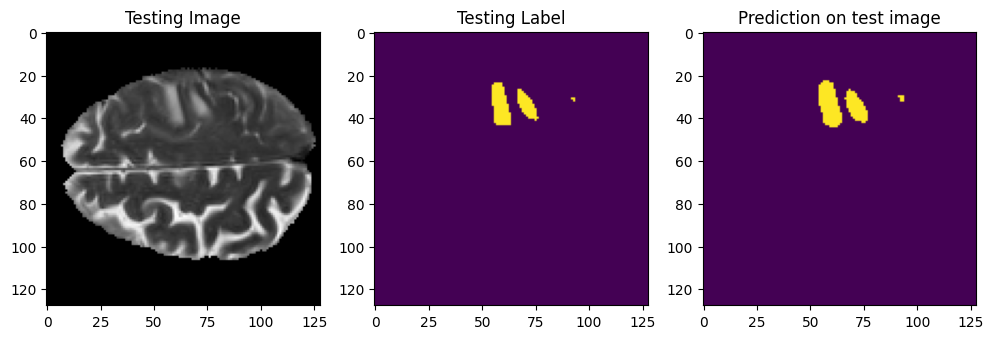

In [27]:
from matplotlib import pyplot as plt
import random

n_slice=random.randint(0, test_prediction_argmax.shape[2])
print(n_slice)
#n_slice = 67
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,n_slice,1], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(test_mask_argmax[:,:,n_slice])
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_prediction_argmax[:,:, n_slice])
plt.show()

In [17]:
img_num = 146

test_img = np.load("/mnt/e/BRaTS/archive (1)/split_data/val/MRIs/MRI_"+str(img_num)+".npy")

test_mask = np.load("/mnt/e/BRaTS/archive (1)/split_data/val/masks/mask_"+str(img_num)+".npy")
test_mask_argmax=np.argmax(test_mask, axis=3)

test_img_input = np.expand_dims(test_img, axis=0)
test_prediction = model.predict(test_img_input)
test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


67


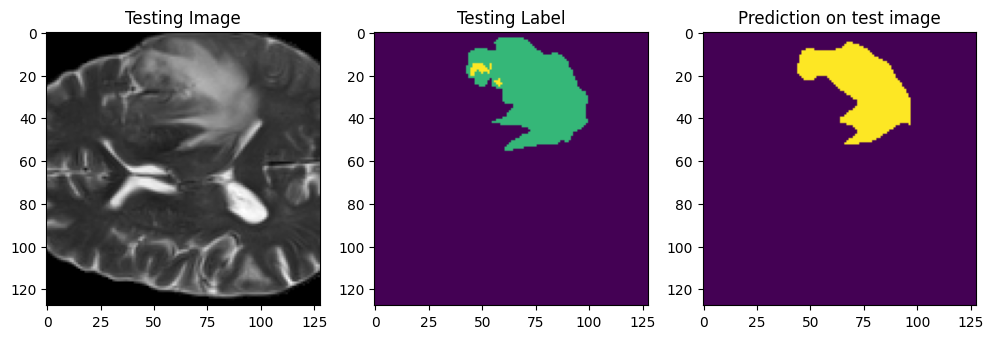

In [31]:
from matplotlib import pyplot as plt
import random

n_slice=random.randint(0, test_prediction_argmax.shape[2])
print(n_slice)
#n_slice = 67
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,n_slice,1], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(test_mask_argmax[:,:,n_slice])
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_prediction_argmax[:,:, n_slice])
plt.show()

# Та же модель

In [7]:
kernel_initializer = 'he_uniform'
def UNet_3D_mine(height, width, depth, channels, classes):
    inputs = Input((height, width, depth, channels))
    #encoder
    conv_block1 = Conv3D(16, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(inputs)
    batchnorm_block1 = BatchNormalization()(conv_block1)
    act_block1 = Activation('relu')(batchnorm_block1)
    conv_block1 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block1)
    batchnorm_block1 = BatchNormalization()(conv_block1)
    act_block1 = Activation('relu')(batchnorm_block1)
    maxpool_block1 = MaxPooling3D((2, 2, 2))(act_block1)

    conv_block2 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block1)
    batchnorm_block2 = BatchNormalization()(conv_block2)
    act_block2 = Activation('relu')(batchnorm_block2)
    conv_block2 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block2)
    batchnorm_block2 = BatchNormalization()(conv_block2)
    act_block2 = Activation('relu')(batchnorm_block2)
    maxpool_block2 = MaxPooling3D((2, 2, 2))(act_block2)

    conv_block3 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block2)
    batchnorm_block3 = BatchNormalization()(conv_block3)
    act_block3 = Activation('relu')(batchnorm_block3)
    conv_block3 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block3)
    batchnorm_block3 = BatchNormalization()(conv_block3)
    act_block3 = Activation('relu')(batchnorm_block3)
    maxpool_block3 = MaxPooling3D((2, 2, 2))(act_block3)

    conv_block4 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block3)
    batchnorm_block4 = BatchNormalization()(conv_block4)
    act_block4 = Activation('relu')(batchnorm_block4)
    conv_block4 = Conv3D(256, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block4)
    batchnorm_block4 = BatchNormalization()(conv_block4)
    act_block4 = Activation('relu')(batchnorm_block4)

    upconv_block5 =  Conv3DTranspose(256, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block4)
    concat_block5 = concatenate([upconv_block5, act_block3])
    conv_block5 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block5)
    batchnorm_block5 = BatchNormalization()(conv_block5)
    act_block5 = Activation('relu')(batchnorm_block5)
    conv_block5 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block5)
    batchnorm_block5 = BatchNormalization()(conv_block5)
    act_block5 = Activation('relu')(batchnorm_block5)

    upconv_block6 =  Conv3DTranspose(128, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block5)
    concat_block6 = concatenate([upconv_block6, act_block2])
    conv_block6 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block6)
    batchnorm_block6 = BatchNormalization()(conv_block6)
    act_block6 = Activation('relu')(batchnorm_block6)
    conv_block6 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block6)
    batchnorm_block6 = BatchNormalization()(conv_block6)
    act_block6 = Activation('relu')(batchnorm_block6)

    upconv_block7 = Conv3DTranspose(32, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block6)
    concat_block7 = concatenate([upconv_block7, act_block1])
    conv_block7 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block7)
    batchnorm_block7 = BatchNormalization()(conv_block7)
    act_block7 = Activation('relu')(batchnorm_block7)
    conv_block7 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block7)
    batchnorm_block7 = BatchNormalization()(conv_block7)
    act_block7 = Activation('relu')(batchnorm_block7)

    outputs = Conv3D(classes, (1, 1, 1), activation='softmax')(act_block7)
    model = Model(inputs=[inputs], outputs=[outputs])
    

    return model

# Ее тренировка с использованием categorical focal loss

In [8]:
from keras.models import Model
from keras.layers import Input, Conv3D, MaxPooling3D, concatenate, Conv3DTranspose, BatchNormalization, Activation
from keras.optimizers import Adam
import numpy as np

In [9]:
train_images = '/mnt/e/BRaTS/archive (1)/split_data/train/MRIs/'
train_masks = '/mnt/e/BRaTS/archive (1)/split_data/train/masks/'

validation_images = '/mnt/e/BRaTS/archive (1)/split_data/val/MRIs/'
validation_masks = '/mnt/e/BRaTS/archive (1)/split_data/val/masks/'

train_images_list = os.listdir(train_images)
train_masks_list = os.listdir(train_masks)

validation_images_list = os.listdir(validation_images)
validation_masks_list = os.listdir(validation_masks)

batch_size = 1

train_generator = MRI_generator(train_images, train_images_list, train_masks, train_masks_list, batch_size)
validation_generator = MRI_generator(validation_images, validation_images_list, validation_masks, validation_masks_list, batch_size)

In [14]:
data_0 = 0
data_1 = 0
data_2 = 0
data_3 = 0
train_mask_list = sorted(glob.glob('/mnt/e/BRaTS/archive (1)/split_data/train/masks/*.npy'))
for img in range(len(train_mask_list)):
    print(img)
    temp_image=np.load(train_mask_list[img])
    temp_image = np.argmax(temp_image, axis=3)
    val, counts = np.unique(temp_image, return_counts=True)
    if val[0] == 0:
        data_0 += counts[0]
    if len(val) > 1 and val[1] == 1:
        data_1 += counts[1]
    if len(val) > 2 and val[2] == 2:
        data_2 += counts[2]
    if len(val) > 3 and val[3] == 3:
        data_3 += counts[3]
    
print(data_0)

label_0 = data_0
label_1 = data_1
label_2 = data_2
label_3 = data_3
total_labels = label_0 + label_1 + label_2 + label_3
n_classes = 4
wt0 = round((total_labels/(n_classes*label_0)), 2)
wt1 = round((total_labels/(n_classes*label_1)), 2)
wt2 = round((total_labels/(n_classes*label_2)), 2)
wt3 = round((total_labels/(n_classes*label_3)), 2)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [6]:
print(weights)

[0.26, 37.43, 9.2, 25.71]


In [10]:
weights = [0.26, 37.43, 9.2, 25.71]

In [11]:
steps_per_epoch = len(train_images_list)//batch_size
validation_steps_per_epoch = len(validation_images_list)//batch_size

model = UNet_3D_mine(height=128, width=128, depth=128, channels=3, classes=4)
LR = 0.000001
optimizer = Adam(LR)
metrics = ['categorical_accuracy', tf.keras.metrics.OneHotMeanIoU(num_classes=4)]
t_loss = tf.keras.losses.CategoricalFocalCrossentropy(alpha=weights)

model.compile(optimizer = optimizer, loss=t_loss, metrics=metrics)
print(model.summary())

I0000 00:00:1748284443.487570  157248 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 128, 128,  │      1,312 │ input_layer[0][0] │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 128, 128,  │     13,856 │ activation[0][0]  │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling3D)      │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 64, 64,    │     27,680 │ max_pooling3d[0]… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 64, 64,    │     55,360 │ activation_2[0][… │
│                     │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling3D)      │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 32, 32,    │    110,656 │ max_pooling3d_1[… │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv3d_4[0][0]  

 Total params: 4,729,860 (18.04 MB)

 Trainable params: 4,727,524 (18.03 MB)

 Non-trainable params: 2,336 (9.12 KB)

None


In [12]:
history=model.fit(train_generator ,
          steps_per_epoch=steps_per_epoch,
          epochs=40,
          verbose=1,
          validation_data=validation_generator,
          validation_steps=validation_steps_per_epoch,
          )

Epoch 1/40


I0000 00:00:1748284468.809327  157598 service.cc:152] XLA service 0x7f7a280034f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748284468.809518  157598 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2025-05-26 21:34:29.281003: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748284470.935656  157598 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-05-26 21:34:33.626168: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=3,k3=0} for conv %cudnn-conv-bias-activation.45 = (f32[1,16,128,128,128]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[1,3,128,128,128]{4,3,2,1,0} %bitcast.15055, f32[16,3,3,3,3]{4,3,2,1,0} %bitcast.13583, f32[16]{0} %bitcast.16987), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="_

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1441s 1s/step - categorical_accuracy: 0.3395 - loss: 0.9544 - one_hot_mean_io_u: 0.1262 - val_categorical_accuracy: 0.3714 - val_loss: 0.7036 - val_one_hot_mean_io_u: 0.1058
Epoch 2/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1353s 1s/step - categorical_accuracy: 0.3958 - loss: 0.7185 - one_hot_mean_io_u: 0.1608 - val_categorical_accuracy: 0.4139 - val_loss: 0.6197 - val_one_hot_mean_io_u: 0.1155
Epoch 3/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1348s 1s/step - categorical_accuracy: 0.4329 - loss: 0.6326 - one_hot_mean_io_u: 0.1802 - val_categorical_accuracy: 0.4444 - val_loss: 0.5806 - val_one_hot_mean_io_u: 0.1224
Epoch 4/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1341s 1s/step - categorical_accuracy: 0.4595 - loss: 0.5806 - one_hot_mean_io_u: 0.1943 - val_categorical_accuracy: 0.4639 - val_loss: 0.5571 - val_one_hot_mean_io_u: 0.1284
Epoch 5/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1344s 1s/step - categorical_accuracy: 0.4836 - loss: 0.5419 - one_hot_mean_io_u: 0.2058 - val_categorical

In [13]:
history.history.keys()

dict_keys(['categorical_accuracy', 'loss', 'one_hot_mean_io_u', 'val_categorical_accuracy', 'val_loss', 'val_one_hot_mean_io_u'])

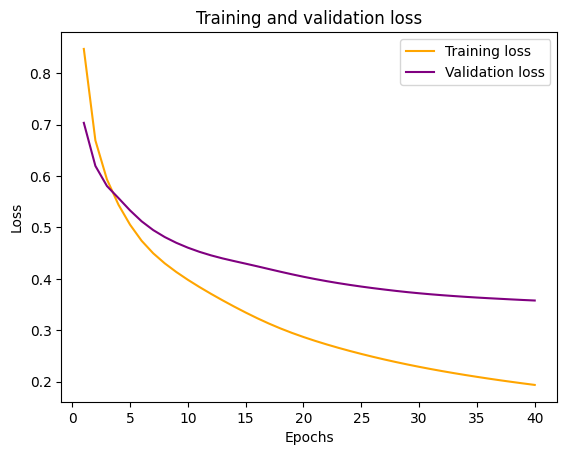

In [14]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, color='orange', label='Training loss')
plt.plot(epochs, val_loss, color='purple', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

[0.3713902235031128, 0.41390499472618103, 0.44437190890312195, 0.46390223503112793, 0.4869644343852997, 0.5100611448287964, 0.5314934849739075, 0.5512591600418091, 0.5694486498832703, 0.5866236090660095, 0.6023955345153809, 0.6171656847000122, 0.6307517886161804, 0.6434578895568848, 0.6560097336769104, 0.6682586073875427, 0.680037796497345, 0.6912054419517517, 0.7016291618347168, 0.7114490270614624, 0.7208549976348877, 0.7298205494880676, 0.7382454872131348, 0.7461194396018982, 0.7535680532455444, 0.760577380657196, 0.7668417692184448, 0.7723349332809448, 0.7772805690765381, 0.7816488742828369, 0.7855547070503235, 0.7890852093696594, 0.7923209071159363, 0.7953159809112549, 0.7980102300643921, 0.800503134727478, 0.8027669787406921, 0.8048526048660278, 0.8067854046821594, 0.8085556626319885]


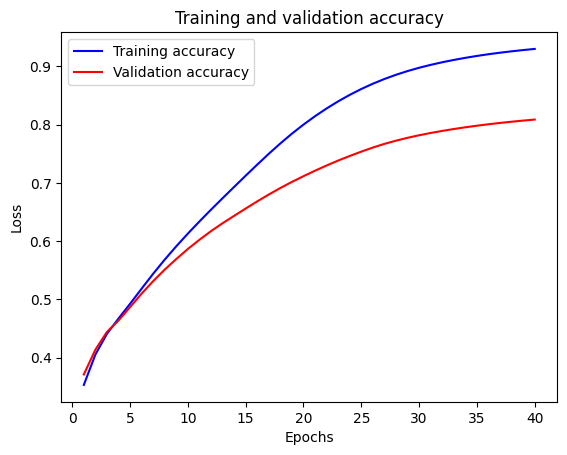

In [15]:
acc = history.history['categorical_accuracy']

val_acc = history.history['val_categorical_accuracy']
print(val_acc)
epochs = range(1, len(loss) + 1)
plt.plot(epochs, acc, color='blue', label='Training accuracy')
plt.plot(epochs, val_acc, color='red' , label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

[0.16136616468429565, 0.19680136442184448, 0.2170373797416687, 0.23022045195102692, 0.24263474345207214, 0.25369176268577576, 0.26155412197113037, 0.26720288395881653, 0.2715569734573364, 0.2751588821411133, 0.2782985270023346, 0.28113675117492676, 0.2837579846382141, 0.2861805558204651, 0.2884489893913269, 0.29056546092033386, 0.29256895184516907, 0.2944716215133667, 0.2962746024131775, 0.29799431562423706, 0.2996392250061035, 0.3012146055698395, 0.30272015929222107, 0.30417555570602417, 0.305583119392395, 0.3069436550140381, 0.3082653880119324, 0.3095468282699585, 0.31078630685806274, 0.312000572681427, 0.31317469477653503, 0.314314603805542, 0.3154327869415283, 0.3165079951286316, 0.31756508350372314, 0.3186051845550537, 0.32169222831726074, 0.3253173530101776, 0.3287944197654724, 0.3321409523487091]


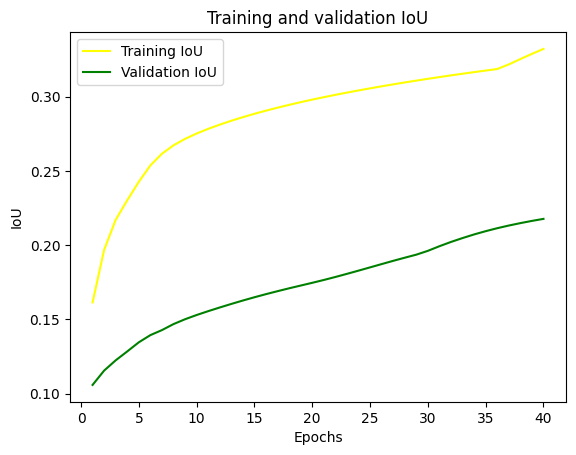

In [21]:
iou = history.history['one_hot_mean_io_u']

val_iou = history.history['val_one_hot_mean_io_u']
print(iou)
epochs = range(1, len(loss) + 1)
plt.plot(epochs, iou, color='yellow', label='Training IoU')
plt.plot(epochs, val_iou, color='green', label='Validation IoU')
plt.title('Training and validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.show()

In [16]:
img_num = 205

test_img = np.load("/mnt/e/BRaTS/archive (1)/split_data/test/MRIs/MRI_"+str(img_num)+".npy")

test_mask = np.load("/mnt/e/BRaTS/archive (1)/split_data/test/masks/mask_"+str(img_num)+".npy")
test_mask_argmax=np.argmax(test_mask, axis=3)

test_img_input = np.expand_dims(test_img, axis=0)
test_prediction = model.predict(test_img_input)
test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


8


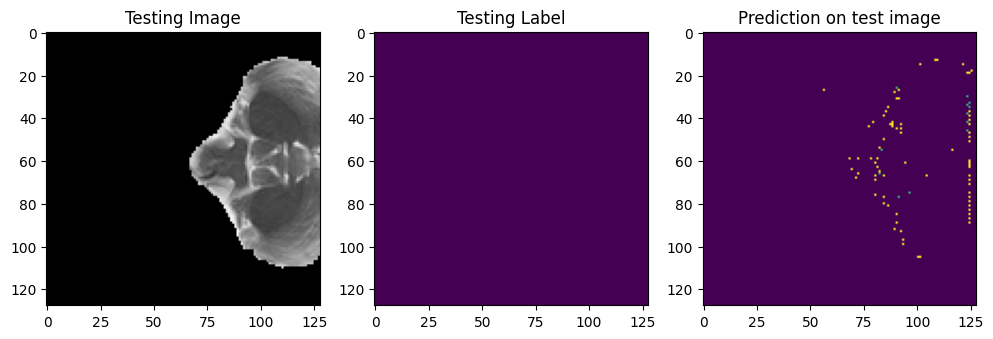

In [17]:
from matplotlib import pyplot as plt
import random

n_slice=random.randint(0, test_prediction_argmax.shape[2])
print(n_slice)
#n_slice = 67
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,n_slice,1], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(test_mask_argmax[:,:,n_slice])
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_prediction_argmax[:,:, n_slice])
plt.show()

In [18]:
img_num = 146

test_img = np.load("/mnt/e/BRaTS/archive (1)/split_data/val/MRIs/MRI_"+str(img_num)+".npy")

test_mask = np.load("/mnt/e/BRaTS/archive (1)/split_data/val/masks/mask_"+str(img_num)+".npy")
test_mask_argmax=np.argmax(test_mask, axis=3)

test_img_input = np.expand_dims(test_img, axis=0)
test_prediction = model.predict(test_img_input)
test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


109


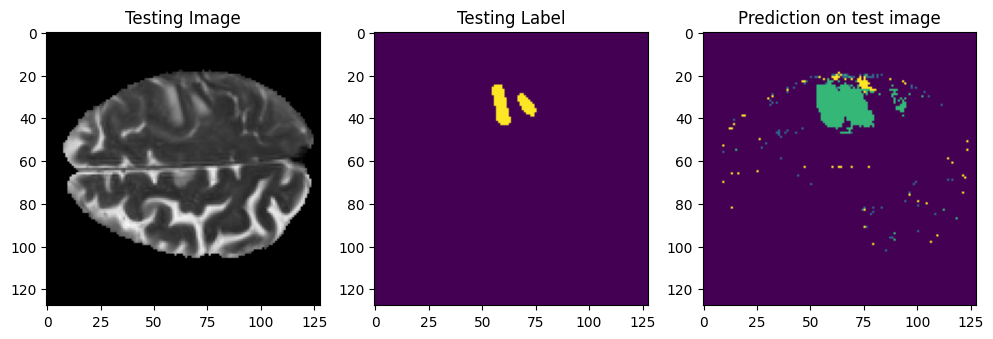

In [20]:
from matplotlib import pyplot as plt
import random

n_slice=random.randint(0, test_prediction_argmax.shape[2])
print(n_slice)
#n_slice = 67
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,n_slice,1], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(test_mask_argmax[:,:,n_slice])
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_prediction_argmax[:,:, n_slice])
plt.show()

# Модель с Dropout для регуляризации

In [7]:
kernel_initializer = 'he_uniform'
def UNet_3D_mine(height, width, depth, channels, classes):
    inputs = Input((height, width, depth, channels))
    #encoder
    conv_block1 = Conv3D(16, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(inputs)
    batchnorm_block1 = BatchNormalization()(conv_block1)
    act_block1 = Activation('relu')(batchnorm_block1)
    drop_block1 = Dropout(0.1)(act_block1)
    conv_block1 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(drop_block1)
    batchnorm_block1 = BatchNormalization()(conv_block1)
    act_block1 = Activation('relu')(batchnorm_block1)
    maxpool_block1 = MaxPooling3D((2, 2, 2))(act_block1)

    conv_block2 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block1)
    batchnorm_block2 = BatchNormalization()(conv_block2)
    act_block2 = Activation('relu')(batchnorm_block2)
    drop_block2 = Dropout(0.2)(act_block2)
    conv_block2 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(drop_block2)
    batchnorm_block2 = BatchNormalization()(conv_block2)
    act_block2 = Activation('relu')(batchnorm_block2)
    maxpool_block2 = MaxPooling3D((2, 2, 2))(act_block2)

    conv_block3 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block2)
    batchnorm_block3 = BatchNormalization()(conv_block3)
    act_block3 = Activation('relu')(batchnorm_block3)
    drop_block3 = Dropout(0.2)(act_block3)
    conv_block3 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(drop_block3)
    batchnorm_block3 = BatchNormalization()(conv_block3)
    act_block3 = Activation('relu')(batchnorm_block3)
    maxpool_block3 = MaxPooling3D((2, 2, 2))(act_block3)

    conv_block4 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block3)
    batchnorm_block4 = BatchNormalization()(conv_block4)
    act_block4 = Activation('relu')(batchnorm_block4)
    drop_block4 = Dropout(0.3)(act_block4)
    conv_block4 = Conv3D(256, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(drop_block4)
    batchnorm_block4 = BatchNormalization()(conv_block4)
    act_block4 = Activation('relu')(batchnorm_block4)

    upconv_block5 =  Conv3DTranspose(256, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block4)
    concat_block5 = concatenate([upconv_block5, act_block3])
    conv_block5 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block5)
    batchnorm_block5 = BatchNormalization()(conv_block5)
    act_block5 = Activation('relu')(batchnorm_block5)
    drop_block5 = Dropout(0.2)(act_block5)
    conv_block5 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(drop_block5)
    batchnorm_block5 = BatchNormalization()(conv_block5)
    act_block5 = Activation('relu')(batchnorm_block5)

    upconv_block6 =  Conv3DTranspose(128, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block5)
    concat_block6 = concatenate([upconv_block6, act_block2])
    conv_block6 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block6)
    batchnorm_block6 = BatchNormalization()(conv_block6)
    act_block6 = Activation('relu')(batchnorm_block6)
    drop_block6 = Dropout(0.2)(act_block6)
    conv_block6 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(drop_block6)
    batchnorm_block6 = BatchNormalization()(conv_block6)
    act_block6 = Activation('relu')(batchnorm_block6)

    upconv_block7 = Conv3DTranspose(32, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block6)
    concat_block7 = concatenate([upconv_block7, act_block1])
    conv_block7 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block7)
    batchnorm_block7 = BatchNormalization()(conv_block7)
    act_block7 = Activation('relu')(batchnorm_block7)
    drop_block7 = Dropout(0.1)(act_block7)
    conv_block7 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(drop_block7)
    batchnorm_block7 = BatchNormalization()(conv_block7)
    act_block7 = Activation('relu')(batchnorm_block7)

    outputs = Conv3D(classes, (1, 1, 1), activation='softmax')(act_block7)
    model = Model(inputs=[inputs], outputs=[outputs])
    

    return model

# Тренировка модели с Dropout

In [8]:
from keras.models import Model
from keras.layers import Input, Conv3D, MaxPooling3D, concatenate, Conv3DTranspose, BatchNormalization, Activation, Dropout
from keras.optimizers import Adam
import segmentation_models_3D as sm
import numpy as np

Segmentation Models: using `keras` framework.


In [9]:
train_images = '/mnt/e/BRaTS/archive (1)/split_data/train/MRIs/'
train_masks = '/mnt/e/BRaTS/archive (1)/split_data/train/masks/'

validation_images = '/mnt/e/BRaTS/archive (1)/split_data/val/MRIs/'
validation_masks = '/mnt/e/BRaTS/archive (1)/split_data/val/masks/'

train_images_list = os.listdir(train_images)
train_masks_list = os.listdir(train_masks)

validation_images_list = os.listdir(validation_images)
validation_masks_list = os.listdir(validation_masks)

batch_size = 1

train_generator = MRI_generator(train_images, train_images_list, train_masks, train_masks_list, batch_size)
validation_generator = MRI_generator(validation_images, validation_images_list, validation_masks, validation_masks_list, batch_size)

In [10]:
steps_per_epoch = len(train_images_list)//batch_size
validation_steps_per_epoch = len(validation_images_list)//batch_size

model = UNet_3D_mine(height=128, width=128, depth=128, channels=3, classes=4)
LR = 0.00001
optimizer = Adam(LR)
metrics = ['categorical_accuracy', tf.keras.metrics.OneHotMeanIoU(num_classes=4)]
t_loss = 'categorical_crossentropy'

model.compile(optimizer = optimizer, loss=t_loss, metrics=metrics)
print(model.summary())

I0000 00:00:1748268394.672975   92509 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 128, 128,  │      1,312 │ input_layer[0][0] │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ activation[0][0]  │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 128, 128,  │     13,856 │ dropout[0][0]     │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling3D)      │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 64, 64,    │     27,680 │ max_pooling3d[0]… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ activation_2[0][… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 64, 64,    │     55,360 │ dropout_1[0][0]   │
│                     │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 32, 32,    │          0 │ activation_3[0][

 Total params: 4,729,860 (18.04 MB)

 Trainable params: 4,727,524 (18.03 MB)

 Non-trainable params: 2,336 (9.12 KB)

None


In [11]:
model.save('/mnt/e/model_dropout.h5')

In [28]:
history=model.fit(train_generator ,
          steps_per_epoch=steps_per_epoch,
          epochs=30,
          verbose=1,
          validation_data=validation_generator,
          validation_steps=validation_steps_per_epoch,
          )

Epoch 1/30


I0000 00:00:1747768227.825444   12229 service.cc:152] XLA service 0x7fe008003770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747768227.825947   12229 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2025-05-20 22:10:29.691761: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747768233.019426   12229 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-05-20 22:10:37.392576: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=3,k3=0} for conv %cudnn-conv-bias-activation.45 = (f32[1,16,128,128,128]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[1,3,128,128,128]{4,3,2,1,0} %bitcast.31713, f32[16,3,3,3,3]{4,3,2,1,0} %bitcast.30182, f32[16]{0} %bitcast.33621), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="_

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1501s 1s/step - categorical_accuracy: 0.6152 - loss: 1.1015 - one_hot_mean_io_u_1: 0.1377 - val_categorical_accuracy: 0.9135 - val_loss: 0.8034 - val_one_hot_mean_io_u_1: 0.1942
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1355s 1s/step - categorical_accuracy: 0.9619 - loss: 0.5074 - one_hot_mean_io_u_1: 0.2307 - val_categorical_accuracy: 0.9338 - val_loss: 0.6053 - val_one_hot_mean_io_u_1: 0.2280
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1349s 1s/step - categorical_accuracy: 0.9650 - loss: 0.3894 - one_hot_mean_io_u_1: 0.2460 - val_categorical_accuracy: 0.9413 - val_loss: 0.4959 - val_one_hot_mean_io_u_1: 0.2532
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1342s 1s/step - categorical_accuracy: 0.9677 - loss: 0.3162 - one_hot_mean_io_u_1: 0.2651 - val_categorical_accuracy: 0.9291 - val_loss: 0.4892 - val_one_hot_mean_io_u_1: 0.2579
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1334s 1s/step - categorical_accuracy: 0.9714 - loss: 0.2617 - one_hot_mean_io_u_1: 0.3140

In [29]:
print(history.history.keys())

dict_keys(['categorical_accuracy', 'loss', 'one_hot_mean_io_u_1', 'val_categorical_accuracy', 'val_loss', 'val_one_hot_mean_io_u_1'])


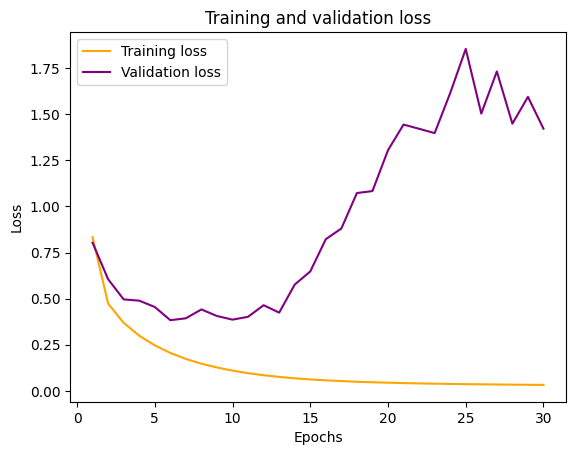

In [30]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, color='orange', label='Training loss')
plt.plot(epochs, val_loss, color='purple', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

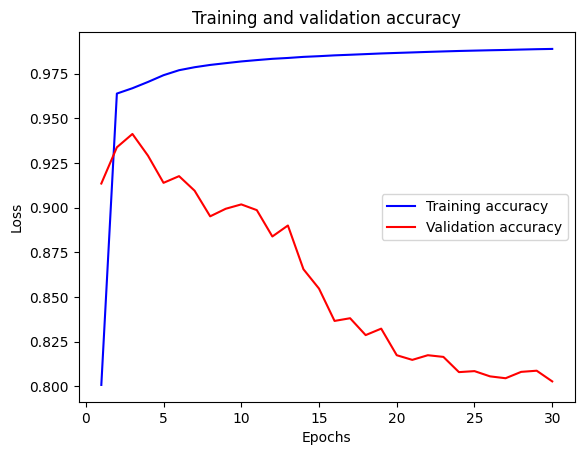

In [31]:
acc = history.history['categorical_accuracy']

val_acc = history.history['val_categorical_accuracy']

epochs = range(1, len(loss) + 1)
plt.plot(epochs, acc, color='blue', label='Training accuracy')
plt.plot(epochs, val_acc, color='red' , label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

[0.13079634308815002, 0.18640166521072388, 0.1990799903869629, 0.2146746963262558, 0.2540295422077179, 0.2992960214614868, 0.3316158652305603, 0.3582824766635895, 0.3808615803718567, 0.4035475254058838, 0.42178916931152344, 0.43877890706062317, 0.4510308802127838, 0.46458426117897034, 0.4745635688304901, 0.4857577681541443, 0.4938517212867737, 0.5028040409088135, 0.5121556520462036, 0.5200313925743103, 0.5269774794578552, 0.5347633361816406, 0.5418210625648499, 0.5487817525863647, 0.554379940032959, 0.5597198009490967, 0.5640455484390259, 0.570044994354248, 0.5751063823699951, 0.5796509385108948]


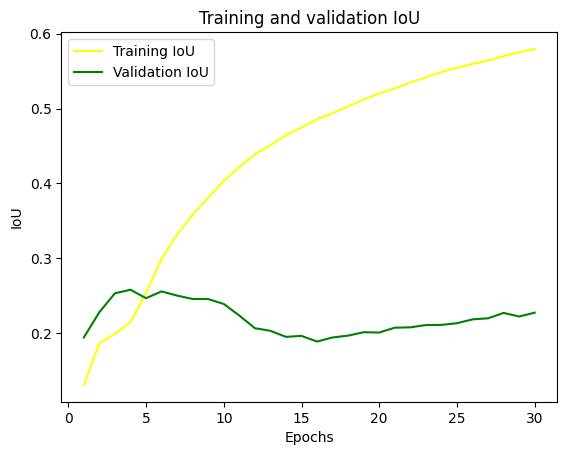

In [32]:
iou = history.history['one_hot_mean_io_u_1']

val_iou = history.history['val_one_hot_mean_io_u_1']
print(iou)
epochs = range(1, len(loss) + 1)
plt.plot(epochs, iou, color='yellow', label='Training IoU')
plt.plot(epochs, val_iou, color='green', label='Validation IoU')
plt.title('Training and validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.show()

# Модель с Dice Loss

In [7]:
kernel_initializer = 'he_uniform'
def UNet_3D_mine(height, width, depth, channels, classes):
    inputs = Input((height, width, depth, channels))
    #encoder
    conv_block1 = Conv3D(16, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(inputs)
    batchnorm_block1 = BatchNormalization()(conv_block1)
    act_block1 = Activation('relu')(batchnorm_block1)
    conv_block1 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block1)
    batchnorm_block1 = BatchNormalization()(conv_block1)
    act_block1 = Activation('relu')(batchnorm_block1)
    maxpool_block1 = MaxPooling3D((2, 2, 2))(act_block1)

    conv_block2 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block1)
    batchnorm_block2 = BatchNormalization()(conv_block2)
    act_block2 = Activation('relu')(batchnorm_block2)
    conv_block2 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block2)
    batchnorm_block2 = BatchNormalization()(conv_block2)
    act_block2 = Activation('relu')(batchnorm_block2)
    maxpool_block2 = MaxPooling3D((2, 2, 2))(act_block2)

    conv_block3 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block2)
    batchnorm_block3 = BatchNormalization()(conv_block3)
    act_block3 = Activation('relu')(batchnorm_block3)
    conv_block3 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block3)
    batchnorm_block3 = BatchNormalization()(conv_block3)
    act_block3 = Activation('relu')(batchnorm_block3)
    maxpool_block3 = MaxPooling3D((2, 2, 2))(act_block3)

    conv_block4 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(maxpool_block3)
    batchnorm_block4 = BatchNormalization()(conv_block4)
    act_block4 = Activation('relu')(batchnorm_block4)
    conv_block4 = Conv3D(256, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block4)
    batchnorm_block4 = BatchNormalization()(conv_block4)
    act_block4 = Activation('relu')(batchnorm_block4)

    upconv_block5 =  Conv3DTranspose(256, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block4)
    concat_block5 = concatenate([upconv_block5, act_block3])
    conv_block5 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block5)
    batchnorm_block5 = BatchNormalization()(conv_block5)
    act_block5 = Activation('relu')(batchnorm_block5)
    conv_block5 = Conv3D(128, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block5)
    batchnorm_block5 = BatchNormalization()(conv_block5)
    act_block5 = Activation('relu')(batchnorm_block5)

    upconv_block6 =  Conv3DTranspose(128, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block5)
    concat_block6 = concatenate([upconv_block6, act_block2])
    conv_block6 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block6)
    batchnorm_block6 = BatchNormalization()(conv_block6)
    act_block6 = Activation('relu')(batchnorm_block6)
    conv_block6 = Conv3D(64, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block6)
    batchnorm_block6 = BatchNormalization()(conv_block6)
    act_block6 = Activation('relu')(batchnorm_block6)

    upconv_block7 = Conv3DTranspose(32, (2, 2, 2), strides=(2, 2, 2), padding='same')(act_block6)
    concat_block7 = concatenate([upconv_block7, act_block1])
    conv_block7 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(concat_block7)
    batchnorm_block7 = BatchNormalization()(conv_block7)
    act_block7 = Activation('relu')(batchnorm_block7)
    conv_block7 = Conv3D(32, (3, 3, 3), kernel_initializer=kernel_initializer, padding='same')(act_block7)
    batchnorm_block7 = BatchNormalization()(conv_block7)
    act_block7 = Activation('relu')(batchnorm_block7)

    outputs = Conv3D(classes, (1, 1, 1), activation='softmax')(act_block7)
    model = Model(inputs=[inputs], outputs=[outputs])
    

    return model

# Тренировка

In [8]:
train_images = '/mnt/e/BRaTS/archive (1)/split_data/train/MRIs/'
train_masks = '/mnt/e/BRaTS/archive (1)/split_data/train/masks/'

validation_images = '/mnt/e/BRaTS/archive (1)/split_data/val/MRIs/'
validation_masks = '/mnt/e/BRaTS/archive (1)/split_data/val/masks/'

train_images_list = os.listdir(train_images)
train_masks_list = os.listdir(train_masks)

validation_images_list = os.listdir(validation_images)
validation_masks_list = os.listdir(validation_masks)

batch_size = 1

train_generator = MRI_generator(train_images, train_images_list, train_masks, train_masks_list, batch_size)
validation_generator = MRI_generator(validation_images, validation_images_list, validation_masks, validation_masks_list, batch_size)

In [9]:
import tensorflow as tf
def Dice_loss(y_true, y_pred, eps=1e-6):
    axis = (1, 2, 3)
    intersection = tf.reduce_sum(y_true * y_pred, axis=axis)
    summ = tf.reduce_sum(y_true, axis=axis) + tf.reduce_sum(y_pred, axis=axis)
    dice_coeff = 2 * intersection / (summ + eps)

    loss = 1 - tf.reduce_mean(dice_coeff, axis=-1)
    return tf.reduce_mean(loss, axis=-1)

In [10]:
steps_per_epoch = len(train_images_list)//batch_size
validation_steps_per_epoch = len(validation_images_list)//batch_size

model = UNet_3D_mine(height=128, width=128, depth=128, channels=3, classes=4)
LR = 0.00001
optimizer = Adam(LR)
metrics = ['categorical_accuracy', tf.keras.metrics.OneHotMeanIoU(num_classes=4)]
d_loss = Dice_loss

model.compile(optimizer = optimizer, loss=d_loss, metrics=metrics)
print(model.summary())

I0000 00:00:1748625171.460422    9417 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 128, 128,  │      1,312 │ input_layer[0][0] │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 128, 128,  │     13,856 │ activation[0][0]  │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling3D)      │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 64, 64,    │     27,680 │ max_pooling3d[0]… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 64, 64,    │     55,360 │ activation_2[0][… │
│                     │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling3D)      │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 32, 32,    │    110,656 │ max_pooling3d_1[… │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv3d_4[0][0]  

 Total params: 4,729,860 (18.04 MB)

 Trainable params: 4,727,524 (18.03 MB)

 Non-trainable params: 2,336 (9.12 KB)

None


In [11]:
history=model.fit(train_generator,
          steps_per_epoch=steps_per_epoch,
          epochs=40,
          verbose=1,
          validation_data=validation_generator,
          validation_steps=validation_steps_per_epoch,
          )

Epoch 1/40


I0000 00:00:1748625262.928533    9905 service.cc:152] XLA service 0x70d0bc035b80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748625262.928579    9905 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2025-05-30 20:14:24.101182: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748625266.724593    9905 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-05-30 20:14:30.538116: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=3,k3=0} for conv %cudnn-conv-bias-activation.45 = (f32[1,16,128,128,128]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[1,3,128,128,128]{4,3,2,1,0} %bitcast.14948, f32[16,3,3,3,3]{4,3,2,1,0} %bitcast.13461, f32[16]{0} %bitcast.16821), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="_

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1464s 1s/step - categorical_accuracy: 0.6212 - loss: 0.7911 - one_hot_mean_io_u: 0.1862 - val_categorical_accuracy: 0.7559 - val_loss: 0.7375 - val_one_hot_mean_io_u: 0.1611
Epoch 2/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1369s 1s/step - categorical_accuracy: 0.8288 - loss: 0.6945 - one_hot_mean_io_u: 0.2703 - val_categorical_accuracy: 0.7658 - val_loss: 0.7067 - val_one_hot_mean_io_u: 0.1929
Epoch 3/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1367s 1s/step - categorical_accuracy: 0.8337 - loss: 0.6568 - one_hot_mean_io_u: 0.3289 - val_categorical_accuracy: 0.7108 - val_loss: 0.6859 - val_one_hot_mean_io_u: 0.1981
Epoch 4/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1361s 1s/step - categorical_accuracy: 0.8253 - loss: 0.6207 - one_hot_mean_io_u: 0.3743 - val_categorical_accuracy: 0.6715 - val_loss: 0.6656 - val_one_hot_mean_io_u: 0.1994
Epoch 5/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1349s 1s/step - categorical_accuracy: 0.8216 - loss: 0.5869 - one_hot_mean_io_u: 0.4067 - val_categorical

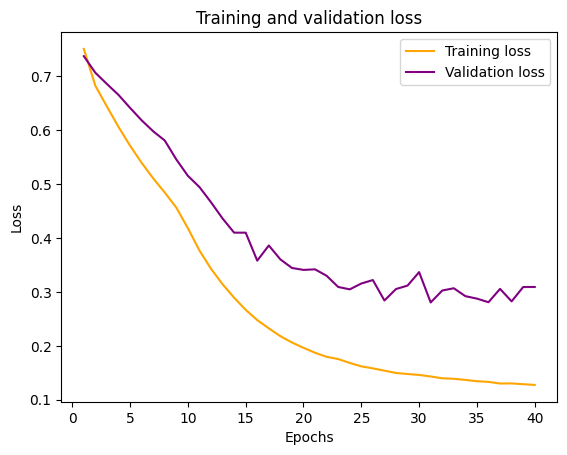

In [12]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, color='orange', label='Training loss')
plt.plot(epochs, val_loss, color='purple', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

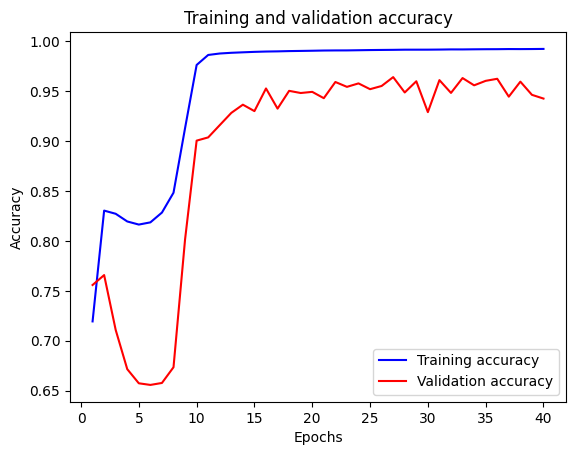

In [28]:
acc = history.history['categorical_accuracy']

val_acc = history.history['val_categorical_accuracy']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, acc, color='blue', label='Training accuracy')
plt.plot(epochs, val_acc, color='red' , label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

[0.23212122917175293, 0.27381259202957153, 0.32650649547576904, 0.3584500849246979, 0.38040995597839355, 0.4045921862125397, 0.42324766516685486, 0.437581866979599, 0.44659698009490967, 0.44538557529449463, 0.5391101837158203, 0.5698953866958618, 0.585793673992157, 0.5969049334526062, 0.608217716217041, 0.6162148714065552, 0.6208797097206116, 0.6278848052024841, 0.6322667598724365, 0.6370354890823364, 0.6428595781326294, 0.645428478717804, 0.6462907195091248, 0.6508098840713501, 0.6558361053466797, 0.6591951847076416, 0.6621730327606201, 0.6664271950721741, 0.6670876741409302, 0.6672306060791016, 0.6698824167251587, 0.6746478080749512, 0.673888623714447, 0.6775723695755005, 0.6801565885543823, 0.6810463666915894, 0.6852705478668213, 0.6831663846969604, 0.685556948184967, 0.6888121366500854]


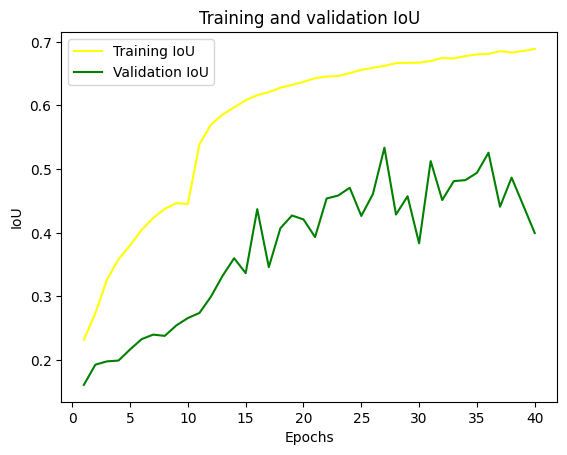

In [14]:
iou = history.history['one_hot_mean_io_u']

val_iou = history.history['val_one_hot_mean_io_u']
print(iou)
epochs = range(1, len(loss) + 1)
plt.plot(epochs, iou, color='yellow', label='Training IoU')
plt.plot(epochs, val_iou, color='green', label='Validation IoU')
plt.title('Training and validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.show()

In [15]:
img_num = 205

test_img = np.load("/mnt/e/BRaTS/archive (1)/split_data/test/MRIs/MRI_"+str(img_num)+".npy")

test_mask = np.load("/mnt/e/BRaTS/archive (1)/split_data/test/masks/mask_"+str(img_num)+".npy")
test_mask_argmax=np.argmax(test_mask, axis=3)

test_img_input = np.expand_dims(test_img, axis=0)
test_prediction = model.predict(test_img_input)
test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


78


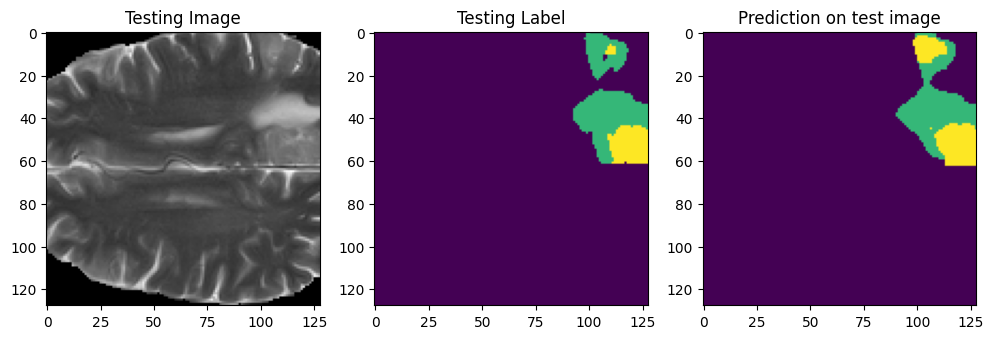

In [23]:
from matplotlib import pyplot as plt
import random

n_slice=random.randint(0, test_prediction_argmax.shape[2])
print(n_slice)
#n_slice = 67
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,n_slice,1], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(test_mask_argmax[:,:,n_slice])
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_prediction_argmax[:,:, n_slice])
plt.show()

In [24]:
img_num = 146

test_img2 = np.load("/mnt/e/BRaTS/archive (1)/split_data/val/MRIs/MRI_"+str(img_num)+".npy")

test_mask2 = np.load("/mnt/e/BRaTS/archive (1)/split_data/val/masks/mask_"+str(img_num)+".npy")
test_mask_argmax2=np.argmax(test_mask2, axis=3)

test_img_input2 = np.expand_dims(test_img2, axis=0)
test_prediction2 = model.predict(test_img_input2)
test_prediction_argmax2=np.argmax(test_prediction2, axis=4)[0,:,:,:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


95


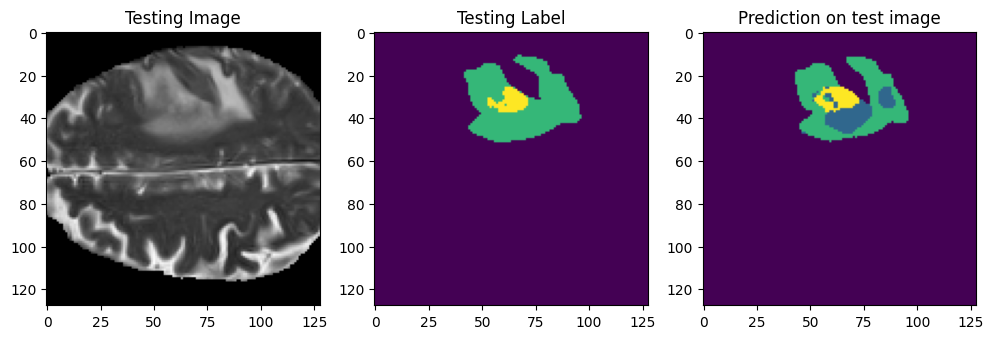

In [27]:
from matplotlib import pyplot as plt
import random

n_slice=random.randint(0, test_prediction_argmax2.shape[2])
print(n_slice)
#n_slice = 67
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img2[:,:,n_slice,1], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(test_mask_argmax2[:,:,n_slice])
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_prediction_argmax2[:,:, n_slice])
plt.show()